In [1]:
import numpy as np
import time
import cosmocnc as cnc
import os

import os
import psutil

def memory_used_mb():
    """Return memory used by this process in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**2  # rss = resident set size

print(f"Memory before init: {memory_used_mb():.2f} MB")

defaulting to  /rds-d4/user/iz221/hpc-work/cosmopower/
defaulting to  /Users/licongxu/csd3/cosmocnc/cosmocnc/../
Memory before init: 616.33 MB


# Initialize
Note that `get_sky_coords = True` only works in full sky, and it just randomly assign sky locations of the clusters. \
For small sky paches, just set `get_sky_coords = False`, and assign coordinate of the clusters on the small patch later on separately

# Set up configuration

In [2]:
# --------------------- Config ---------------------
sky_frac = 1.0
get_sky_coords = True 

# Two parameter files: catalogue_sbi_0.csv and catalogue_sbi_1.csv
# indices = [0, 1]
indices = np.arange(5)
# param_dir = "../catalogue_demo"
param_dir = "../catalogue_batches"
param_tpl = "params_sbi_{idx}.csv"

# One catalogue per run of catalogue_generator
n_catalogues = 1
# Where to save generated catalogues
save_tpl = "../catalogue_generated/catalogue_test_{idx}.npy"
# sky_frac
# indices


# Initialization
Principle is from $p(M,z) \propto dN/(dMdz)$ 
### Note the precision parameters `n_points` ($N_M$) and `n_z` ($N_z$), to generate real true catalogues they should be set very high
#### Currently, to save time and memory `n_points=1024` and `n_z=10000` for demonstration purposes
##### Experience shows `n_points=1024*64` and `n_z=10000` might be the correct setting, which takes an RAM of 54080 MB (8 icelake-himem per task on csd3)
##### Note we do not set scaling parameters here if we just want halo catalogue in (M,z)
#### Mass is in $1 \times 10 ^{14} M_\odot$ unit

In [3]:
cnc_params = {
    "number_cores_hmf": 1,
    # "n_points": 1024*64, #RAM=6760*8 MB
    # "n_z": 10000, 
    "n_points": 1024, #N_M
    "n_z": 1000,  #N_z
    "z_min": 0.005,
    "z_max": 3.0,
    "M_min": 1e14,
    "M_max": 1e16,
    "cosmo_model": "lcdm",
    "hmf_type": "Tinker08",
    "mass_definition": "500c",
    "cosmology_tool": "classy_sz",
    "hmf_calc": "cnc",
    "hmf_type_deriv": "numerical",
    "power_spectrum_type": "cosmopower",
    # "cosmo_amplitude_parameter": "logA", #sigma8
    "cosmo_amplitude_parameter": "sigma_8", #sigma8
    "cosmo_param_density": "physical",
    "interp_tinker": "log",
    "class_sz_cosmo_model": "lcdm",
    "cosmocnc_verbose": "none",
    "load_catalogue": False,
    "survey_sr": "/Users/licongxu/csd3/cosmocnc/surveys/survey_sr_so_sim.py",
    "survey_cat": "/Users/licongxu/csd3/cosmocnc/surveys/survey_cat_so_sim.py",
    "class_sz_ndim_masses": 100,
    "class_sz_ndim_redshifts": 500,
    "class_sz_concentration_parameter": "B13",
    "class_sz_output": "mPk,m500c_to_m200c,m200c_to_m500c",
    "class_sz_hmf": "T08M500c",
    "class_sz_use_m500c_in_ym_relation": 1,
    "class_sz_use_m200c_in_ym_relation": 0,
    "observables": [["q_so_sim"]],
    "obs_select": "q_so_sim",
    "stacked_likelihood": False,
    "obs_select_min": 0.0,
    "obs_select_max": 0.0,
}

# Baseline cosmology; will be overwritten per-catalogue from CSV
cosmo_params = {
    "h": 0.6766,
    "Ob0h2": 0.02242,
    "Oc0h2": 0.1193,
    # "logA": 3.047,
    "sigma_8": 0.78,
    "n_s": 0.9665,
    "m_nu": 0.06,
    "tau_reio": 0.0544,
}

scal_rel_params = {
    }

# --------------------------------------------------
print(f"Memory use after setting scaling relation params: {memory_used_mb():.2f} MB")

Memory use after setting scaling relation params: 616.53 MB


In [4]:
# Initialise number counts once
number_counts = cnc.cluster_number_counts(cnc_params=cnc_params)
number_counts.cosmo_params = cosmo_params
number_counts.scal_rel_params = scal_rel_params
number_counts.initialise()
print("Initialised number_counts.")

print(f"Memory after init: {memory_used_mb():.2f} MB")

/Users/licongxu/csd3/cosmocnc/cosmocnc/cnc.py:65: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology = cosmology_model(cosmo_params=self.cosmo_params,
/Users/licongxu/envs/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


Initialised number_counts.
Memory after init: 497.25 MB


### Check the current cosmological parameters

In [5]:
# print all cosmological parameters (input + derived) used by CLASS‑SZ
print("Cosmological parameters after initialisation:")
for k, v in number_counts.cosmology.cosmo_params.items():
    print(f"{k}: {v}")

Cosmological parameters after initialisation:
h: 0.6766
Ob0h2: 0.02242
Oc0h2: 0.1193
sigma_8: 0.7800000000000209
n_s: 0.9665
m_nu: 0.06
tau_reio: 0.0544
Ob0: 0.04897468161869667
Om0: 0.30957590896528514
A_s: 1.9527109742006737e-09
Onu0: 0.00140720597643018


### If you want to update the cosmological parameters, do not re-initialize, just do `number_counts.update_params(cosmo_params, scal_rel_params)`

In [6]:
# Update cosmology 
cosmo_params["h"] = 0.68
cosmo_params["logA"] = 3.047
cosmo_params["n_s"] = 0.965
cosmo_params["Ob0h2"] = 0.022
cosmo_params["Oc0h2"] = 0.12
number_counts.update_params(cosmo_params, scal_rel_params)

/Users/licongxu/csd3/cosmocnc/cosmocnc/cnc.py:138: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology.update_cosmology(cosmo_params,cosmology_tool=self.cnc_params["cosmology_tool"])
/Users/licongxu/envs/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


In [7]:
print("Current cosmology parameters:")
for k, v in number_counts.cosmology.cosmo_params.items():
    print(f"{k}: {v}")

Current cosmology parameters:
h: 0.68
Ob0h2: 0.022
Oc0h2: 0.12
sigma_8: 0.7800000000001143
n_s: 0.965
m_nu: 0.06
tau_reio: 0.0544
Ob0: 0.04757785467128026
Om0: 0.30709342560553626
A_s: 1.9229240482527537e-09
Onu0: 0.001393169096815289
logA: 3.047


# Generate cluster catalogues from parameters
### Note: use classy_sz post23 here

In [8]:
t0 = time.time()
 # Update cosmology from the CSV (ignore the last four irrelevant params)
cosmo_params["h"] = 0.6766
cosmo_params["logA"] = 2.9718
cosmo_params["n_s"] = 0.9665
cosmo_params["Ob0h2"] = 0.02242
cosmo_params["Oc0h2"] = 0.1193
number_counts.update_params(cosmo_params, scal_rel_params)

    # Reproducible seed per catalogue
unique_seed = 0
np.random.seed(unique_seed)

cat_gen = cnc.catalogue_generator(
number_counts=number_counts,
n_catalogues=n_catalogues,
seed=unique_seed,
get_sky_coords=get_sky_coords,
sky_frac=sky_frac,
)
cat_gen.generate_catalogues_hmf()
print(f"Memory use after generating catalogues: {memory_used_mb():.2f} MB")
catalogue_list = cat_gen.catalogue_list
catalogue = catalogue_list[0]

M = catalogue["M"]
z = catalogue["z"]
print("N clusters:", len(M))
print("Time generation (s):", time.time() - t0)

/Users/licongxu/csd3/cosmocnc/cosmocnc/cnc.py:138: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology.update_cosmology(cosmo_params,cosmology_tool=self.cnc_params["cosmology_tool"])
/Users/licongxu/envs/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


Sky frac 1.0
Memory use after generating catalogues: 609.64 MB
N clusters: 307173
Time generation (s): 12.70961594581604


In [9]:
print("Type of catalogue:", type(catalogue))
print(catalogue)

Type of catalogue: <class 'dict'>
{'z': array([0.3669038 , 0.35770021, 1.15894945, ..., 0.67441071, 0.77103098,
       0.25354417]), 'M': array([1.44204865, 1.36830887, 1.24699303, ..., 1.00403345, 1.37365738,
       3.36884951]), 'lon': array([3.2625369 , 0.4328801 , 3.95988315, ..., 5.71846129, 3.03529838,
       3.64681876]), 'lat': array([0.10674888, 1.36240323, 0.46748924, ..., 1.70199192, 1.72038692,
       2.43154322])}


## Benchmark the generated catalogue from HMF
### Check the generated HMF is consistent with the theory
(Note there is an issue here not understanding: computing theoretical prediction need to use lower precision parameter on `n_z` to make things agree, ask Íñigo to check this)

In [10]:
import scipy.integrate as integrate
hmf_matrix = number_counts.hmf_matrix
lnM = number_counts.ln_M
# print("M is",np.exp(lnM))
z = number_counts.redshift_vec
# print("z is", z)
dn_dz = integrate.simpson(hmf_matrix,x=lnM,axis=1)*4*np.pi*sky_frac
dn_dlnM = integrate.simpson(hmf_matrix,x=z,axis=0)*4*np.pi*sky_frac
N_tot = integrate.simpson(dn_dz,x=z)

print("Total number of clusters in theory is",N_tot)

Total number of clusters in theory is 307097.49559817696


### Plot the theoretical and empirical histograms for $N$ vs. $M$ and $N$ vs. $z$.
#### From the theoretical input:

In [11]:
z_bins_edges = np.linspace(0.005,3,20)
ln_M_bins_edges = np.linspace(np.log(1),np.log(100),20)


# print("z_bins_edges",z_bins_edges)
# print("ln_M_bins_edges",ln_M_bins_edges)

z_bins_centres = (z_bins_edges[0:-1]+z_bins_edges[1:])*0.5
ln_M_bins_centres = (ln_M_bins_edges[0:-1]+ln_M_bins_edges[1:])*0.5

def integrate_bins(bins_edges,x,dn_dx):

    n_x = np.zeros(len(bins_edges)-1)

    for i in range(0,len(bins_edges)-1):

        x_interp = np.linspace(bins_edges[i],bins_edges[i+1],100)
        dn_dx_interp = np.interp(x_interp,x,dn_dx)
        n_x[i] = integrate.simpson(dn_dx_interp,x=x_interp)

    return n_x

n_z = integrate_bins(z_bins_edges,z,dn_dz)
n_ln_M = integrate_bins(ln_M_bins_edges,lnM,dn_dlnM)
print("Shape of n_z is",n_z.shape)
print("Shape of n_ln_M is",n_ln_M.shape)

Shape of n_z is (19,)
Shape of n_ln_M is (19,)


#### From the generated catalogue:

In [12]:
z_hist,z_x = np.histogram(np.array(catalogue['z']),bins=z_bins_edges)
lnM_hist,lnM_x = np.histogram(np.log(catalogue['M']),bins=ln_M_bins_edges)

### Plot the histogram for comparison

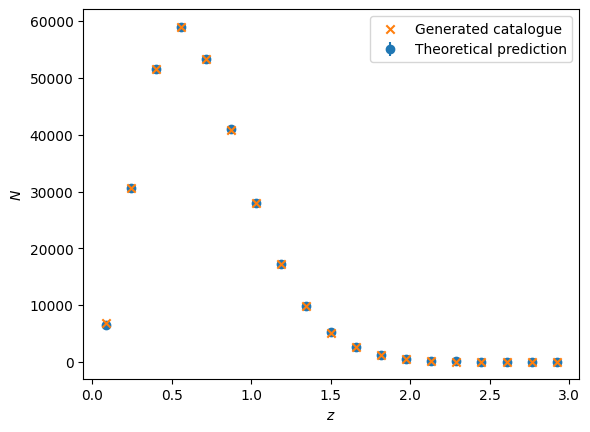

In [13]:
import matplotlib.pyplot as plt
plt.errorbar(z_bins_centres,n_z,yerr=np.sqrt(n_z),linestyle="none",fmt="o",zorder=0, label="Theoretical prediction")
plt.scatter(z_bins_centres,z_hist,marker="x",color="C1",zorder=1, label="Generated catalogue")
plt.xlabel("$z$")
plt.ylabel("$N$")
plt.legend()
plt.show()

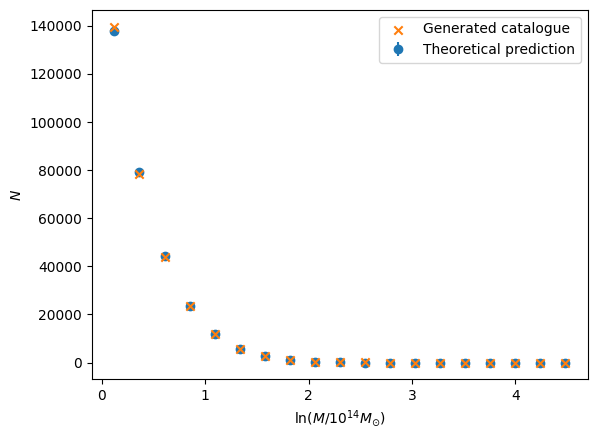

In [14]:
plt.errorbar(ln_M_bins_centres,n_ln_M,yerr=np.sqrt(n_ln_M),linestyle="none",fmt="o",zorder=0, label="Theoretical prediction")
plt.scatter(ln_M_bins_centres,lnM_hist,marker="x",color="C1",zorder=1, label="Generated catalogue")
plt.xlabel("$\\ln(M/10^{14}M_{\\odot})$")
plt.ylabel("$N$")
plt.legend()
plt.show()

#### Compare the difference between theory and generated catalogue with theoretical Poisson error bars to determine precision parameters `n_points` and `n_z`, I found `n_points`$\approx 2^{14}$ to $2^{17}$ and `n_z`$=10000$.
-- Note I am skeptical about this, things are "made to be agreed" to use lower precision parameters in theoretical predictions \
Here I use low precision parameters so things not agree

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/var/folders/pk/xl4598515pb7q2jfw1tdzyr00000gn/T/ipykernel_56444/2447427981.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta N$")


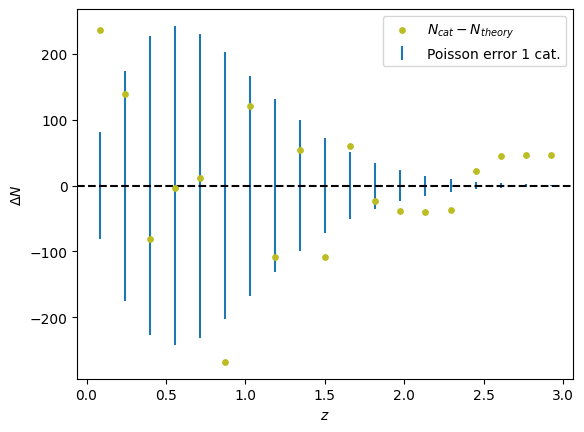

In [20]:
plt.errorbar(z_bins_centres,n_z-n_z,yerr=np.sqrt(n_z),linestyle="none",fmt="",zorder=0,label="Poisson error 1 cat.")
# plt.errorbar(z_bins_centres ,n_z-n_z,yerr=np.sqrt(n_z)/np.sqrt(10.),linestyle="none",fmt="",color="tab:red",zorder=5,label="Poisson error 10 cat.")
plt.scatter(z_bins_centres,z_hist-n_z,s=15,color='tab:olive',zorder=10,label="$N_{cat} - N_{theory}$")
plt.axhline(y=0,linestyle="dashed",color="k")
plt.xlabel("$z$")
plt.ylabel("$\Delta N$")
plt.legend()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/var/folders/pk/xl4598515pb7q2jfw1tdzyr00000gn/T/ipykernel_56444/1348833020.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta N$")


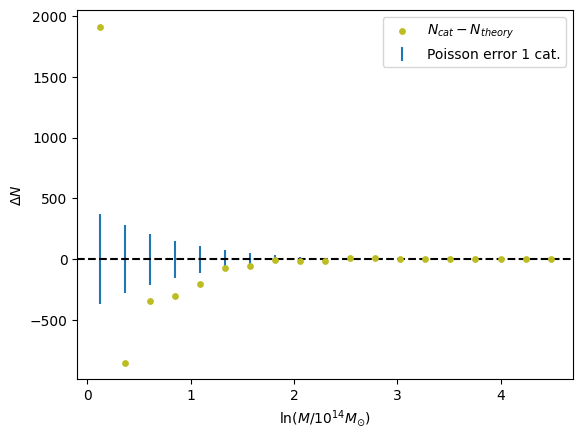

In [21]:
plt.errorbar(ln_M_bins_centres,n_ln_M-n_ln_M,yerr=np.sqrt(n_ln_M),linestyle="none",fmt="",zorder=0,label="Poisson error 1 cat.")
# plt.errorbar(z_bins_centres ,n_z-n_z,yerr=np.sqrt(n_z)/np.sqrt(10.),linestyle="none",fmt="",color="tab:red",zorder=5,label="Poisson error 10 cat.")
plt.scatter(ln_M_bins_centres,lnM_hist-n_ln_M,s=15,color='tab:olive',zorder=10,label="$N_{cat} - N_{theory}$")
plt.axhline(y=0,linestyle="dashed",color="k")
plt.xlabel("$\\ln(M/10^{14}M_{\\odot})$")
plt.ylabel("$\Delta N$")
plt.legend()
plt.show()